# Load data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("training_data/rdbms_all_methods_training_data.parquet")
# df = pd.read_parquet("training_data/rdbms_training_data.parquet")
# rename min_cut_upper to min_cut
df.rename(columns={"min_cut_upper": "min_cut"}, inplace=True)
print(df.columns.tolist())

['RowKey', 'num_agg_funcs', 'num_and_clauses', 'num_subqueries_with', 'num_eq_predicates', 'num_group_bys', 'num_join_occurrences', 'num_joins', 'num_unique_join_edges', 'num_order_bys', 'num_select_columns', 'num_where_clauses', 'num_qubits', 'width', 'depth', 'circuit_size', 'pauli_gate_count', 'two_qubit_gate_count', 'two_qubit_gate_percentage', 'locality_ratio', 'idling_score', 'density_score', 'gate_counts', 'statevector_saved_sparsity', 'statevector_saved_shannon_entropy', 'statevector_saved_von_neumann_entropy', 'edge_count', 'max_degree', 'min_cut', 'diameter', 'radius', 'average_degree', 'average_clustering_coefficient', 'average_shortest_path_length', 'central_point_of_dominance', 'std_dev_adjacency_matrix', 'infiniquantum_execution_time', 'rdbms_execution_time', 'infiniquantum_gate_counts', 'infiniquantum_memory_usage', 'infiniquantum_transpiled_depth', 'infiniquantum_transpiled_size', 'rdbms_ducksql_memory_mb', 'rdbms_ducksql_time_s', 'rdbms_np_mps_memory_mb', 'rdbms_np_mps

In [2]:
SQL_FEATURES = [
    "num_joins",
    "num_and_clauses",
    "num_select_columns",
    "num_agg_funcs",
    "num_where_clauses",
    "num_eq_predicates",
]

GRAPH_FEATURES = [
    "edge_count",
    "max_degree",
    "min_cut",
    "diameter",
    "radius",
    "average_degree",
    "average_clustering_coefficient",
    "average_shortest_path_length",
    "central_point_of_dominance",
    "std_dev_adjacency_matrix",
]

STATIC_FEATURES = [
    "num_qubits",
    "width",
    "depth",
    "circuit_size",
    "pauli_gate_count",
    "two_qubit_gate_count",
    "two_qubit_gate_percentage",
    "locality_ratio",
    "idling_score",
    "density_score",
]

DYNAMIC_FEATURES = [
    "statevector_saved_sparsity",
    "statevector_saved_shannon_entropy",
    # "statevector_saved_von_neumann_entropy",
]

ALL_FEATURES = SQL_FEATURES + GRAPH_FEATURES + STATIC_FEATURES + DYNAMIC_FEATURES

# BUG FIX< statevector saved part of statevector...>

In [3]:
df.drop(columns=[c for c in df.columns if "statevector_saved_e" in c or "statevector_saved_m" in c], inplace=True)

# Construct y target variable

In [4]:
RDBMS_METHODS = ["sqlite", "ducksql","psql",]
QISKIT_METHODS = ["density_matrix", "matrix_product_state", "extended_stabilizer", "statevector",]


ALL_METHODS = RDBMS_METHODS + QISKIT_METHODS
# concatenate for all m in ALL_METHODS, the columns that contain m and end with time_s or execution_time
timecols = []
memcols = []
for m in ALL_METHODS:
    timecols.extend([c for c in df.columns if m in c and c.endswith(("time_s", "execution_time"))])
    memcols.extend([c for c in df.columns if m in c and c.endswith(("memory_usage", "mb"))])
print("Time columns:", timecols)
print("Memory columns:", memcols)

Time columns: ['rdbms_sqlite_time_s', 'rdbms_ducksql_time_s', 'rdbms_psql_time_s', 'density_matrix_execution_time', 'matrix_product_state_execution_time', 'extended_stabilizer_execution_time', 'statevector_execution_time']
Memory columns: ['rdbms_sqlite_memory_mb', 'rdbms_ducksql_memory_mb', 'rdbms_psql_memory_mb', 'density_matrix_memory_usage', 'matrix_product_state_memory_usage', 'extended_stabilizer_memory_usage', 'statevector_memory_usage']


In [5]:
# Build method -> column mapping
time_cols = {
    m: [c for c in timecols if m in c]
    for m in ALL_METHODS
}

mem_cols = {
    m: [c for c in memcols if m in c]
    for m in ALL_METHODS
}

# Remove methods that actually have no columns
time_cols = {m: cols for m, cols in time_cols.items() if len(cols) > 0}
mem_cols  = {m: cols for m, cols in mem_cols.items() if len(cols) > 0}

# Vectorized min-per-method
time_min_df = pd.DataFrame({
    m: df[cols].min(axis=1)
    for m, cols in time_cols.items()
})

mem_min_df = pd.DataFrame({
    m: df[cols].min(axis=1)
    for m, cols in mem_cols.items()
})

# Best method per row
df["best_time_method"] = time_min_df.idxmin(axis=1)
df["best_mem_method"]  = mem_min_df.idxmin(axis=1)

TARGETS = ["best_time_method", "best_mem_method"]

df = df[ALL_FEATURES + TARGETS]

print(f"DataFrame shape: {df.shape} with columns: {df.columns.tolist()}")


DataFrame shape: (162, 30) with columns: ['num_joins', 'num_and_clauses', 'num_select_columns', 'num_agg_funcs', 'num_where_clauses', 'num_eq_predicates', 'edge_count', 'max_degree', 'min_cut', 'diameter', 'radius', 'average_degree', 'average_clustering_coefficient', 'average_shortest_path_length', 'central_point_of_dominance', 'std_dev_adjacency_matrix', 'num_qubits', 'width', 'depth', 'circuit_size', 'pauli_gate_count', 'two_qubit_gate_count', 'two_qubit_gate_percentage', 'locality_ratio', 'idling_score', 'density_score', 'statevector_saved_sparsity', 'statevector_saved_shannon_entropy', 'best_time_method', 'best_mem_method']


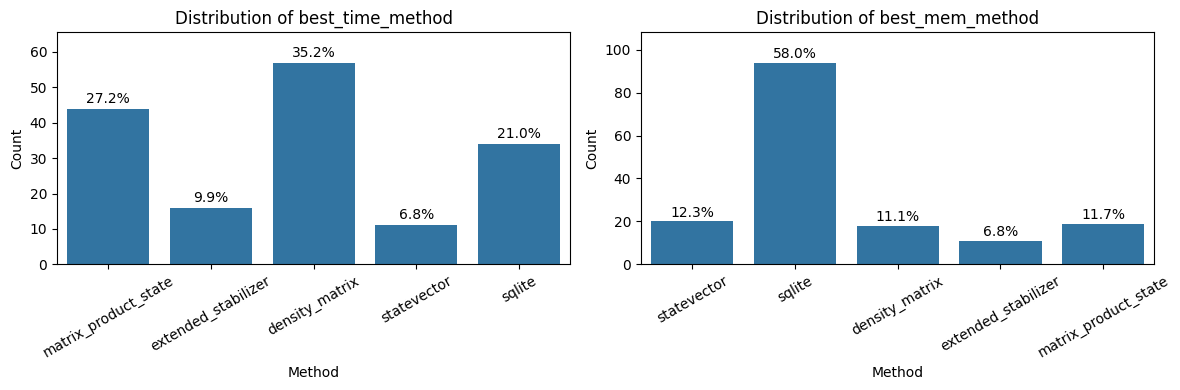

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, target in enumerate(TARGETS):
    ax = axes[i]
    sns.countplot(x=target, data=df, ax=ax)

    ax.set_title(f"Distribution of {target}")
    ax.set_xlabel("Method")
    ax.set_ylabel("Count")

    total = len(df)

    # Add percentage labels
    for p in ax.patches:
        count = p.get_height()
        percentage = f"{100 * count / total:.1f}%"
        x = p.get_x() + p.get_width() / 2
        y = count

        ax.text(x, y + total * 0.005, percentage,
                ha="center", va="bottom", fontsize=10)

    # Add headroom so labels don't overflow
    ymax = max(p.get_height() for p in ax.patches)
    ax.set_ylim(0, ymax * 1.15)

    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Unique values in best_time_method before: ['matrix_product_state' 'extended_stabilizer' 'density_matrix'
 'statevector' 'sqlite']
Unique values in best_mem_method before: ['statevector' 'sqlite' 'density_matrix' 'extended_stabilizer'
 'matrix_product_state']
Unique values in best_time_method before: ['QISKIT' 'RDBMS']
Unique values in best_mem_method before: ['QISKIT' 'RDBMS']


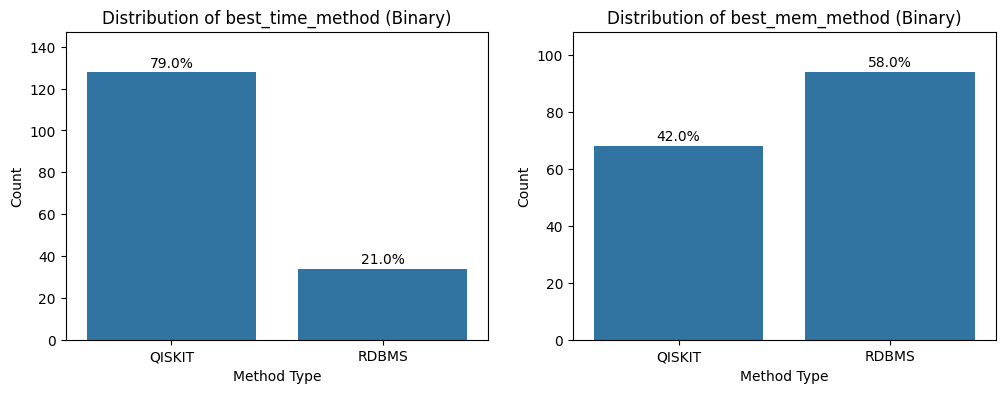

In [7]:
#Lets now replace the TARGETS wit a binary classification of whether the best method is RDBMS or QISKIT. 

print("Unique values in best_time_method before:", df["best_time_method"].unique())
print("Unique values in best_mem_method before:", df["best_mem_method"].unique())

df["best_time_method"] = df["best_time_method"].apply(lambda m: "RDBMS" if m in RDBMS_METHODS else "QISKIT")
df["best_mem_method"]  = df["best_mem_method"].apply(lambda m: "RDBMS" if m in RDBMS_METHODS else "QISKIT")

print("Unique values in best_time_method before:", df["best_time_method"].unique())
print("Unique values in best_mem_method before:", df["best_mem_method"].unique())


# Let us plot a histogram of the new binary targets.
# How many times is RDBMS the best time method vs QISKIT? And same for memory.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, target in enumerate(TARGETS):
    ax = axes[i]
    sns.countplot(x=target, data=df, ax=ax)

    ax.set_title(f"Distribution of {target} (Binary)")
    ax.set_xlabel("Method Type")
    ax.set_ylabel("Count")

    total = len(df)

    # Add percentage labels
    for p in ax.patches:
        count = p.get_height()
        percentage = f"{100 * count / total:.1f}%"
        x = p.get_x() + p.get_width() / 2
        y = count

        ax.text(x, y + total * 0.005, percentage,
                ha="center", va="bottom", fontsize=10)

    # Add headroom so labels don't overflow
    ymax = max(p.get_height() for p in ax.patches)
    ax.set_ylim(0, ymax * 1.15)

# Perform ablation study

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier


TARGET = TARGETS[0]   # or TARGETS[1]
RANDOM_STATE = 42
TEST_SIZE = 0.2

df = df.reset_index(drop=True)

X = df[ALL_FEATURES]
y = df[TARGET]

# Encode labels for XGBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [9]:

from utils import PlotConfusionReports

try:
    train_idx = np.load("train_idx.npy")
    test_idx = np.load("test_idx.npy")
    print("Loaded saved train/test split")

except FileNotFoundError:

    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_encoded
    )

    np.save("train_idx.npy", train_idx)
    np.save("test_idx.npy", test_idx)

    print("Created and saved train/test split")



feature_sets = {
    "Static": STATIC_FEATURES,

    "Static + Graph":
        STATIC_FEATURES + GRAPH_FEATURES,

    "Static + SQL":
        STATIC_FEATURES + SQL_FEATURES,

    "Static + Dynamic":
        STATIC_FEATURES + DYNAMIC_FEATURES,

    "Static + Graph + SQL":
        STATIC_FEATURES + GRAPH_FEATURES + SQL_FEATURES,

    "Static + Graph + SQL + Dynamic":
        STATIC_FEATURES + GRAPH_FEATURES + SQL_FEATURES + DYNAMIC_FEATURES
}

def create_model():
    # return XGBClassifier(
    #     n_estimators=300,
    #     max_depth=6,
    #     learning_rate=0.05,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=RANDOM_STATE,
    #     n_jobs=-1,
    #     eval_metric="logloss"
    # )
    return XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42
    )


results = []

for setting_name, cols in feature_sets.items():

    cols = [c for c in cols if c in df.columns]

    print(f"Running: {setting_name}")

    X_train = df.iloc[train_idx][cols]
    X_test = df.iloc[test_idx][cols]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    model = create_model()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]   # probability of positive class

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    auc = roc_auc_score(y_test, probs)

    results.append({
        "Features": setting_name,
        "Num Features": len(cols),
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": auc
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1", ascending=False)

print("\nAblation Results:\n")
print(results_df)


results_df.to_csv(f"ablation_results_{TARGET}_{len(df)}.csv", index=False)

print(f"\nSaved results to ablation_results_{TARGET}_{len(df)}.csv")

Loaded saved train/test split
Running: Static
Running: Static + Graph
Running: Static + SQL
Running: Static + Dynamic
Running: Static + Graph + SQL
Running: Static + Graph + SQL + Dynamic

Ablation Results:

                         Features  Num Features  Accuracy        F1   ROC-AUC
2                    Static + SQL            16  0.939394  0.833333  0.956044
4            Static + Graph + SQL            26  0.909091  0.727273  0.983516
3                Static + Dynamic            12  0.878788  0.714286  0.961538
0                          Static            10  0.848485  0.666667  0.912088
1                  Static + Graph            20  0.878788  0.666667  0.928571
5  Static + Graph + SQL + Dynamic            28  0.878788  0.666667  0.967033

Saved results to ablation_results_best_time_method_162.csv


In [10]:
import pandas as pd
import numpy as np

def check_dataset_suspicious(X, y):
    print("=== Dataset Diagnostics ===")
    
    n_samples, n_features = X.shape
    print(f"Number of samples: {n_samples}")
    print(f"Number of features: {n_features}")
    
    # Ensure y is a Series for convenience
    if isinstance(y, np.ndarray):
        y_series = pd.Series(y)
    else:
        y_series = y
        
    n_classes = y_series.nunique()
    print(f"Number of classes: {n_classes}")
    
    class_counts = y_series.value_counts(normalize=True)
    print(f"Class distribution:\n{class_counts}\n")
    
    # 1. Low-variance / constant features
    low_var_thresh = 1e-5
    low_var_cols = X.columns[X.var() < low_var_thresh].tolist()
    print(f"Low-variance / constant features ({len(low_var_cols)}): {low_var_cols}\n")
    
    # 2. Feature correlation with target
    correlations = {}
    for col in X.columns:
        if pd.api.types.is_numeric_dtype(X[col]):
            correlations[col] = np.corrcoef(X[col], y_series)[0,1]
    corr_series = pd.Series(correlations).abs().sort_values(ascending=False)
    print("Top 5 features most correlated with target (absolute value):")
    print(corr_series.head(5))
    if corr_series.head(1).values[0] > 0.95:
        print("\n⚠️ Warning: Some features are extremely correlated with the target (possible leakage)!\n")
    
    # 3. Check for duplicated rows
    dup_rows = X.duplicated().sum()
    print(f"Number of duplicated rows: {dup_rows}")
    
    # 4. Check for small dataset
    if n_samples < 50:
        print("⚠️ Warning: Very small dataset (<50 samples) – results may be unstable\n")
    
    print("=== End of diagnostics ===\n")


# Example usage
check_dataset_suspicious(X, y_encoded)

=== Dataset Diagnostics ===
Number of samples: 162
Number of features: 28
Number of classes: 2
Class distribution:
0    0.790123
1    0.209877
Name: proportion, dtype: float64

Low-variance / constant features (0): []

Top 5 features most correlated with target (absolute value):
idling_score                         0.473273
statevector_saved_shannon_entropy    0.426163
num_qubits                           0.412932
two_qubit_gate_percentage            0.325696
width                                0.301606
dtype: float64
Number of duplicated rows: 0
=== End of diagnostics ===

